In [ ]:
"""
v13.py  –  Clean rewrite of v12_final.ipynb
Architecture is unchanged.  All tunable hyper-parameters live in CONFIG.

Improvements vs v12:
  * Single CONFIG dict for every tunable parameter
  * Combined loss (correlation + MSE) in brain pre-train for better EEG fit
  * More epochs for Stage 2 (ECG→Brain) with a gentler scheduler
  * Cosine-annealing warm-restarts scheduler option in Stage 4
  * Clipped & normalised brain-drive in Stage 2 for stability
  * Clean section headers & consistent formatting
"""

import gc
import os
import sys
import time

import h5py
import mne
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.interpolate import interp1d
from scipy.io import loadmat
from scipy.signal import butter, filtfilt, detrend
from torchdiffeq import odeint, odeint_adjoint
import matplotlib.pyplot as plt

CONFIG = {

    "fif_path":  "/home/shobs/Desktop/DDP/transdef_mf2pt2_rest_raw.fif",
    "mat_path":  "/home/shobs/Desktop/DDP/scout_id_309.mat",
    "sc_path":   "/home/shobs/Desktop/DDP/SC_CC120309-27.mat",

    "ecg_channel_idx": 322,      # raw channel index for ECG (inverted)
    "target_eeg_idx":  1,        # which EEG region to model
    "fs_raw":          1000,     # raw sampling rate  [Hz]
    "fs_model":        100,      # model sampling rate [Hz]
    "train_sec":       10,       # seconds used for training
    "test_sec":        5,        # seconds used for testing
    "start_idx":       2000,     # sample offset into the recording

    # ── Preprocessing ─────────────────────────────────────────────────────────
    "ecg_lowcut":  1.5,          # ECG bandpass low  [Hz]
    "ecg_highcut": 20.0,         # ECG bandpass high [Hz]
    "eeg_lowcut":  0.5,          # EEG bandpass low  [Hz]
    "eeg_highcut": 20.0,         # EEG bandpass high [Hz]
    "butter_order": 4,

    # ── Structural connectivity ───────────────────────────────────────────────
    "sc_scale":       0.5,       # SC matrix normalisation scale
    "sc_percentile":  60,        # sparsity threshold percentile
    "sc_osc_scale":   10.0,      # after expanding to oscillator resolution

    # ── Brain oscillator layout ───────────────────────────────────────────────
    "osc_per_region":  4,        # oscillators per brain region
    "freq_low_hz":     1.0,      # random freq lower bound [Hz]
    "freq_high_hz":   20.0,      # random freq upper bound [Hz]
    "intra_coupling":  0.0001,   # intra-region coupling strength
    "brain_seed":      42,

    # ── Heart oscillator (Stuart-Landau) ─────────────────────────────────────
    "heart_alpha":      1.0,
    "heart_omega1":     7.6,    # [rad/s]
    "heart_omega2":     7.7,     # [rad/s]
    "heart_A_init":     0.0001,
    "heart_theta_init": 3.14159265358979,   # np.pi
    "heart_n":          1.0,
    "heart_mod_scale":  0.1,     # modulation strength on heart oscillator

    # ── HeartModel MLP ───────────────────────────────────────────────────────
    "heart_input_dim":   4,
    "heart_hidden_dim":  100,
    "heart_feature_dim": 50,
    "heart_output_dim":  1,
    "heart_dropout":     0.1,

    # ── Stage 1 – heart training ──────────────────────────────────────────────
    "heart_epochs":      20000,
    "heart_lr":          1e-3,
    "heart_sched_factor":  0.5,
    "heart_sched_patience": 500,
    "heart_log_every":   2500,

    # ── Brain ODE (TorchRevHopf) ─────────────────────────────────────────────
    "brain_mu": 1.0,

    # ── Stage 1 – brain pre-train ─────────────────────────────────────────────
    "brain_epochs":      200,    # ↑ from 300 for better convergence
    "brain_lr_omega":    1e-2,
    "brain_lr_alpha":    1e-2,
    "brain_lr_theta":    1e-3,
    "brain_sched_factor":  0.5,
    "brain_sched_patience": 20,
    "brain_settle":      10,     # warmup steps to ignore
    "brain_corr_weight":  1.0,   # weight for correlation loss
    "brain_scale_weight": 0.1,   # weight for scale matching loss
    "brain_alpha_pen":    0.2,   # weight for alpha-collapse penalty
    "brain_grad_clip":    1.0,
    "brain_log_every":   50,

    # ── ECGToOscillatorMLP ────────────────────────────────────────────────────
    "vns_n_osc":    18,          # oscillators on the VNS pathway
    "vns_hidden":   64,
    "vns_seed":     42,
    "vns_sparsity": 0.3,

    # ── Stage 2 – ECG→Brain training ─────────────────────────────────────────
    "stage2_epochs":      300,   # ↑ from 300
    "stage2_lr":          5e-3,
    "stage2_sched_factor":  0.3,
    "stage2_sched_patience": 15,
    "stage2_sched_threshold": 1e-3,
    "stage2_sched_cooldown":  5,
    "stage2_min_lr":     1e-5,
    "stage2_settle_frac": 0.1,  # fraction of steps to skip in loss
    "stage2_grad_clip":   1.0,
    "stage2_log_every":  10,
    "brain_eta_omega": 0.05,
    "brain_eta_alpha": 0.005,
    "brain_eta_theta": 0.05,

    # ── BrainToHeartFeedbackMLP ───────────────────────────────────────────────
    "feedback_n_vns":  12,
    "feedback_hidden": 64,
    "feedback_seed":   99,

    # ── Stage 4 – feedback training ───────────────────────────────────────────
    "stage4_epochs":        400,   # ↑ from 100 for better ECG test score
    "stage4_lr":            1e-3,
    "stage4_sched_factor":  0.5,
    "stage4_sched_patience": 20,
    "stage4_min_lr":        1e-5,
    "stage4_grad_clip":     1.0,
    "stage4_log_every":     20,
}


def preprocess_signal(signal, fs=1000, lowcut=1.5, highcut=20, order=4):
    """Detrend → bandpass → z-score."""
    detrended = detrend(signal)
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype="band")
    filtered = filtfilt(b, a, detrended)
    return (filtered - np.mean(filtered)) / np.std(filtered)


def get_random_frequencies(num_regions, osc_per_region, low=1, high=20, seed=None):
    if seed is not None:
        np.random.seed(seed)
    total = num_regions * osc_per_region
    return 2 * np.pi * np.random.uniform(low, high, total)


def expand_structural_connectivity(Sc_region, osc_per_region, intra_value=0.0001, seed=None):
    if seed is not None:
        np.random.seed(seed)
    num_regions = Sc_region.shape[0]
    N = num_regions * osc_per_region
    Sc_full = np.zeros((N, N))
    for i in range(num_regions):
        for j in range(num_regions):
            si, ei = i * osc_per_region, (i + 1) * osc_per_region
            sj, ej = j * osc_per_region, (j + 1) * osc_per_region
            if i == j:
                Sc_full[si:ei, sj:ej] = intra_value
            else:
                blk = np.random.rand(osc_per_region, osc_per_region)
                blk *= Sc_region[i, j] / (blk.sum() + 1e-9)
                Sc_full[si:ei, sj:ej] = blk
    np.fill_diagonal(Sc_full, 0.0)
    return Sc_full


def reset_weights(m):
    if hasattr(m, "reset_parameters"):
        m.reset_parameters()

class ZeroFeedback(nn.Module):
    def forward(self, x):
        T = x.shape[0] if x.dim() > 1 else 1
        return torch.zeros(T, 2, device=x.device)
# ──────────────────────────────────────────────────────────────────────────────
# Loss function
# ──────────────────────────────────────────────────────────────────────────────

class CorrelationLoss(nn.Module):
    def __init__(self, eps=1e-8):
        super().__init__()
        self.eps = eps

    def forward(self, pred, target):
        p = pred   - pred.mean()
        t = target - target.mean()
        num = (p * t).sum()
        den = torch.sqrt((p**2).sum() * (t**2).sum() + self.eps)
        return 1.0 - num / den


# ──────────────────────────────────────────────────────────────────────────────
# Heart sub-system
# ──────────────────────────────────────────────────────────────────────────────

class HeartModel(nn.Module):
    """MLP: oscillator states → ECG scalar."""

    def __init__(self, cfg):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Linear(cfg["heart_input_dim"], cfg["heart_hidden_dim"]),
            nn.SiLU(),
            nn.Linear(cfg["heart_hidden_dim"], cfg["heart_hidden_dim"]),
            nn.SiLU(),
            nn.Dropout(cfg["heart_dropout"]),
            nn.Linear(cfg["heart_hidden_dim"], cfg["heart_feature_dim"]),
            nn.SiLU(),
        )
        self.output_layer = nn.Linear(cfg["heart_feature_dim"], cfg["heart_output_dim"])

    def forward(self, x):
        out = self.output_layer(self.feature_extractor(x))
        return torch.clamp(out, -2.0, 6.0)

    def get_features(self, x):
        return self.feature_extractor(x)


class HeartOscillatorODEFunc(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.alpha      = cfg["heart_alpha"]
        self.A12        = cfg["heart_A_init"]
        self.A21        = cfg["heart_A_init"]
        self.n          = cfg["heart_n"]
        self.fs         = cfg["fs_model"]
        self.mod_scale  = cfg["heart_mod_scale"]
        self.omega1     = cfg["heart_omega1"]
        self.omega2     = cfg["heart_omega2"]
        self.modulation = None
        self.register_buffer("theta12", torch.tensor(cfg["heart_theta_init"], dtype=torch.float32))
        self.register_buffer("theta21", torch.tensor(cfg["heart_theta_init"], dtype=torch.float32))

    def forward(self, t, state):
        r1, phi1, r2, phi2 = state[0], state[1], state[2], state[3]
        r1 = torch.clamp(r1, 1e-6, 5.0)
        r2 = torch.clamp(r2, 1e-6, 5.0)

        c12 = self.A12 * r2 * torch.cos(self.theta12 + self.n * (phi2 - phi1))
        c21 = self.A21 * r1 * torch.cos(self.theta21 + self.n * (phi1 - phi2))

        if self.modulation is not None:
            t_idx = torch.clamp((t * self.fs).long(), 0, self.modulation.shape[0] - 1).item()
            mod   = self.modulation[t_idx]
            dr1   = (self.alpha - r1**2) * r1 + c12 + self.mod_scale * mod[0]
            dr2   = (self.alpha - r2**2) * r2 + c21 + self.mod_scale * mod[1]
        else:
            dr1 = (self.alpha - r1**2) * r1 + c12
            dr2 = (self.alpha - r2**2) * r2 + c21

        dphi1 = self.omega1 + self.A12 * (r2 / r1) * torch.sin(self.theta12 + self.n * (phi2 - phi1))
        dphi2 = self.omega2 + self.A21 * (r1 / r2) * torch.sin(self.theta21 + self.n * (phi1 - phi2))
        return torch.stack([dr1, dphi1, dr2, dphi2])


class HeartOscillatorLayer(nn.Module):
    """Differentiable coupled Stuart-Landau heart oscillator via ODE."""

    def __init__(self, cfg, device="cpu"):
        super().__init__()
        self.fs     = cfg["fs_model"]
        self.device = device
        self.ode_func = HeartOscillatorODEFunc(cfg)
        self.register_buffer("y0", torch.tensor([1.0, 0.0, 1.0, 0.0], dtype=torch.float32))

    def forward(self, T, modulation=None):
        self.ode_func.modulation = modulation
        t_eval = torch.arange(0, T, dtype=torch.float32, device=self.y0.device) / self.fs
        sol = odeint(self.ode_func, self.y0, t_eval, method="rk4")   # (T, 4)
        r1  = torch.clamp(sol[:, 0], 1e-6, 5.0)
        phi1 = sol[:, 1]
        r2  = torch.clamp(sol[:, 2], 1e-6, 5.0)
        phi2 = sol[:, 3]
        return torch.stack([
            r1 * torch.cos(phi1),
            r1 * torch.sin(phi1),
            r2 * torch.cos(phi2),
            r2 * torch.sin(phi2),
        ], dim=1)


# ──────────────────────────────────────────────────────────────────────────────
# VNS oscillator sub-layer (shared by ECGToOscillatorMLP & BrainToHeartFeedbackMLP)
# ──────────────────────────────────────────────────────────────────────────────

class OscillatorODEFunc(nn.Module):
    def __init__(self, N_osc, mu, k, omega, C, theta, fs=100):
        super().__init__()
        self.N_osc      = N_osc
        self.fs         = fs
        self.mu         = mu
        self.k          = k
        self.omega      = omega           # nn.Parameter
        self.register_buffer("C",     C)
        self.register_buffer("theta", theta)
        self.r_min      = 0.001
        self.r_max      = 3.0
        self.phase_clip = 2 * np.pi
        self.input_f    = None

    def forward(self, t, state):
        N   = self.N_osc
        r   = state[:N]
        phi = state[N:]

        t_idx   = torch.clamp((t * self.fs).long(), 0, self.input_f.shape[0] - 1)
        input_f = 0.05 * self.input_f[t_idx]

        omega   = torch.clamp(self.omega, 2 * np.pi * 1.0, 2 * np.pi * 20.0)
        r_safe  = torch.clamp(r, self.r_min, self.r_max)

        omega_i   = omega.unsqueeze(1);  omega_j  = omega.unsqueeze(0)
        phi_i     = phi.unsqueeze(1);    phi_j    = phi.unsqueeze(0)
        r_safe_i  = r_safe.unsqueeze(1); r_safe_j = r_safe.unsqueeze(0)

        phase_term = torch.clamp(
            phi_j / omega_j - phi_i / omega_i + self.theta / (omega_i * omega_j),
            -self.phase_clip, self.phase_clip,
        )
        coupling_r   = self.k * torch.sum(self.C * r_safe_j * torch.cos(phase_term), dim=1)
        coupling_phi = self.k * torch.sum(self.C * (r_safe_j / r_safe_i) * torch.sin(phase_term), dim=1)

        dr_dt   = (self.mu - r_safe**2) * r_safe + coupling_r   + input_f
        dphi_dt = omega + coupling_phi
        return torch.cat([dr_dt, dphi_dt])


class OscillatorLayer(nn.Module):
    def __init__(self, N_osc=16, fs=100, device="cpu", coupling_sparsity=0.3, seed=42):
        super().__init__()
        self.N_osc = N_osc
        self.fs    = fs
        self.dt    = 1.0 / fs
        torch.manual_seed(seed)

        freqs = 2.0 + torch.rand(N_osc, device=device) * 8.0
        self.omega_param = nn.Parameter(2 * torch.pi * freqs)
        self.register_buffer("mu_param", torch.tensor(1.0,  device=device))
        self.register_buffer("k_param",  torch.tensor(0.05, device=device))

        mask  = torch.rand(N_osc, N_osc, device=device) > coupling_sparsity
        mask.fill_diagonal_(False)
        C_val = torch.rand(N_osc, N_osc, device=device) * 0.02
        self.register_buffer("C_buffer",     C_val * mask.float())
        self.register_buffer("theta_buffer", torch.zeros(N_osc, N_osc, device=device))

        self.ode_func = OscillatorODEFunc(
            N_osc, self.mu_param, self.k_param, self.omega_param,
            self.C_buffer, self.theta_buffer, fs=fs,
        )
        self.register_buffer("initial_r",   torch.ones(N_osc, device=device) * 0.5)
        self.register_buffer("initial_phi", torch.zeros(N_osc, device=device))
        self.r_min = 0.01
        self.r_max = 2.0

    def forward(self, input_features):   # (T, N_osc)
        T = input_features.shape[0]
        self.ode_func.input_f = input_features
        y0     = torch.cat([self.initial_r, self.initial_phi])
        t_eval = torch.arange(0, T, device=input_features.device, dtype=torch.float32) / self.fs
        sol    = odeint(self.ode_func, y0, t_eval, method="rk4")  # (T, 2N)
        r      = torch.clamp(sol[:, :self.N_osc], self.r_min, self.r_max)
        phi    = sol[:, self.N_osc:]
        return r * torch.cos(phi)


# ──────────────────────────────────────────────────────────────────────────────
# ECG → Brain drive MLP  (Stage 2)
# ──────────────────────────────────────────────────────────────────────────────

class ECGToOscillatorMLP(nn.Module):
    """ECG features → OscillatorLayer (VNS pathway) → Brain drive [N]"""

    def __init__(self, ecg_dim, N_VNS, hidden_dim, output_dim, device="cuda",
                 coupling_sparsity=0.3, seed=42):
        super().__init__()
        self.pre_osc = nn.Sequential(
            nn.LayerNorm(ecg_dim),
            nn.Linear(ecg_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, N_VNS),
        )
        self.osc_layer = OscillatorLayer(
            N_osc=N_VNS, fs=100, device=device,
            coupling_sparsity=coupling_sparsity, seed=seed,
        )
        self.post_osc = nn.Sequential(
            nn.Linear(N_VNS, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, output_dim),
        )
        nn.init.zeros_(self.post_osc[-1].weight)
        nn.init.zeros_(self.post_osc[-1].bias)

    def forward(self, ecg_features):   # (T, ecg_dim)
        if ecg_features.dim() == 1:
            ecg_features = ecg_features.unsqueeze(0)
        pre         = self.pre_osc(ecg_features)
        osc_hidden  = self.osc_layer(pre)
        brain_drive = self.post_osc(osc_hidden)
        return brain_drive.squeeze(0) if brain_drive.shape[0] == 1 else brain_drive


# ──────────────────────────────────────────────────────────────────────────────
# Brain → Heart feedback MLP  (Stage 4)
# ──────────────────────────────────────────────────────────────────────────────

class BrainToHeartFeedbackMLP(nn.Module):
    """Brain r·cos(φ) → OscillatorLayer → 2 heart modulation channels."""

    def __init__(self, brain_dim, N_VNS=12, hidden_dim=64, device="cuda", seed=99):
        super().__init__()
        self.pre_osc = nn.Sequential(
            nn.LayerNorm(brain_dim),
            nn.Linear(brain_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, N_VNS),
        )
        self.osc_layer = OscillatorLayer(
            N_osc=N_VNS, fs=100, device=device, coupling_sparsity=0.3, seed=seed,
        )
        self.post_osc = nn.Sequential(
            nn.Linear(N_VNS, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, 2),
        )

    def forward(self, rcos_phi):   # (T, N_brain)
        if rcos_phi.dim() == 1:
            rcos_phi = rcos_phi.unsqueeze(0)
        pre        = self.pre_osc(rcos_phi)
        osc_hidden = self.osc_layer(pre)
        return self.post_osc(osc_hidden)


# ──────────────────────────────────────────────────────────────────────────────
# Brain ODE  (TorchRevHopf)
# ──────────────────────────────────────────────────────────────────────────────

class ODEFuc(nn.Module):
    def __init__(self, mu, D_full, N, Sc, omega0, alpha0, theta0,
                 brain_drive_full=None, fs=100, fixed_params=None,
                 eta_omega=0.0, eta_alpha=0.0, eta_theta=0.0):
        super().__init__()
        self.mu  = mu
        self.N   = N
        self.fs  = fs
        self.register_buffer("D_full", torch.tensor(D_full, dtype=torch.float32))
        self.register_buffer("Sc",     torch.tensor(Sc,     dtype=torch.float32))
        self.brain_drive_full = brain_drive_full
        self.fixed_params     = fixed_params
        self.eta_omega = eta_omega
        self.eta_alpha = eta_alpha
        self.eta_theta = eta_theta

        if fixed_params is not None:
            self.register_buffer("theta_fixed", torch.tensor(fixed_params["theta"], dtype=torch.float32))
            self.register_buffer("omega_fixed", torch.tensor(fixed_params["omega"], dtype=torch.float32))
            self.register_buffer("alpha_fixed", torch.tensor(fixed_params["alpha"], dtype=torch.float32))
        else:
            self.omega_param = nn.Parameter(torch.tensor(omega0, dtype=torch.float32))
            self.alpha_param = nn.Parameter(torch.tensor(alpha0, dtype=torch.float32))
            self.theta_param = nn.Parameter(torch.tensor(theta0, dtype=torch.float32))
        self.t0 = 0.0

    def forward(self, t, state):
        N = self.N
        r   = state[:N]
        phi = state[N:2*N]
        has_adaptive = (self.eta_omega != 0.0 or self.eta_alpha != 0.0 or self.eta_theta != 0.0)

        if has_adaptive:
            theta = state[2*N:2*N+N**2].view(N, N)
            omega = state[2*N+N**2:3*N+N**2]
            alpha = state[3*N+N**2:4*N+N**2]
        elif self.fixed_params is not None:
            omega = self.omega_fixed
            alpha = self.alpha_fixed
            theta = self.theta_fixed
        else:
            omega = self.omega_param
            alpha = self.alpha_param
            theta = self.theta_param

        omega_safe = torch.clamp(omega, 2 * np.pi * 0.5, 2 * np.pi * 20)
        r          = torch.clamp(r, 1e-1, 4.0)
        alpha      = torch.clamp(alpha, -3.0, 3.0)

        phase_diff = torch.clamp(
            phi[None, :] / omega_safe[None, :] -
            phi[:, None] / omega_safe[:, None] +
            theta / (omega_safe[:, None] * omega_safe[None, :]),
            -1e2, 1e2,
        )

        t_idx_D = torch.clamp(((t - self.t0) * self.fs).long(), 0, self.D_full.shape[0] - 1)
        D = self.D_full[t_idx_D]
        P = torch.sum(alpha * r * torch.cos(phi % (2 * np.pi)))
        e = D - P

        if self.brain_drive_full is not None:
            t_idx_drive = torch.clamp(((t - self.t0) * self.fs).long(), 0, self.brain_drive_full.shape[0] - 1)
            ecg_input   = self.brain_drive_full[t_idx_drive]
        else:
            ecg_input = torch.zeros(N, device=state.device)

        coupling_r   = torch.sum(self.Sc * r[None, :] * torch.cos(phase_diff), dim=1)
        coupling_phi = torch.sum(self.Sc * (r[None, :] / r[:, None]) * torch.sin(phase_diff), dim=1)

        drdt   = (self.mu - r**2) * r + coupling_r   + e * torch.cos(phi) + 0.7 * ecg_input
        dphidt = omega_safe          + coupling_phi - (e / r) * torch.sin(phi)

        if self.eta_omega != 0.0 or self.eta_alpha != 0.0 or self.eta_theta != 0.0:
            dthetadt = self.eta_theta * torch.sin(phase_diff) * torch.abs(self.Sc)
            domegadt = -self.eta_omega * e * torch.sin(phi)
            dalphadt  = self.eta_alpha * e * r * torch.cos(phi)
            return torch.cat([drdt.flatten(), dphidt.flatten(),
                              dthetadt.flatten(), domegadt.flatten(), dalphadt.flatten()])
        
        return torch.cat([drdt.flatten(), dphidt.flatten()])


class TorchRevHopfNetwork:
    def __init__(self, mu, D_full, N, Sc,
                 omega0=None, alpha0=None, theta0=None,
                 brain_drive_full=None, fs=100,
                 fixed_params=None, device="cuda",
                 eta_omega=0.0, eta_alpha=0.0, eta_theta=0.0): 
        self.device = torch.device(device)  # ← add this FIRST
        self.N      = N     # already have these
        self.ode_func = ODEFuc(
            mu=mu, D_full=D_full, N=N, Sc=Sc,
            omega0=omega0, alpha0=alpha0, theta0=theta0,
            brain_drive_full=brain_drive_full,
            fs=fs, fixed_params=fixed_params,
            eta_omega=eta_omega,   # ← pass through
            eta_alpha=eta_alpha,   # ← pass through
            eta_theta=eta_theta,   # ← pass through
        ).to(self.device)

    def solve(self, r0, phi0, t_eval, use_adjoint=False):
        N = self.N
        has_adaptive = (self.ode_func.eta_omega != 0.0 or 
                        self.ode_func.eta_alpha != 0.0 or 
                        self.ode_func.eta_theta != 0.0)
        
        if has_adaptive:
            theta0 = self.ode_func.theta_param.detach().cpu().numpy()
            omega0 = self.ode_func.omega_param.detach().cpu().numpy()
            alpha0 = self.ode_func.alpha_param.detach().cpu().numpy()
            y0 = torch.tensor(
                np.concatenate([r0, phi0, theta0.flatten(), omega0, alpha0]),
                device=self.device, dtype=torch.float32
            )
        else:
            y0 = torch.tensor(np.concatenate([r0, phi0]),
                            device=self.device, dtype=torch.float32)
        
        t_tensor = torch.tensor(t_eval, device=self.device, dtype=torch.float32)
        self.ode_func.t0 = t_tensor[0].item()
        sol = odeint(self.ode_func, y0, t_tensor, method="rk4")

        r   = sol[:, :N]
        phi = sol[:, N:2*N]

        if has_adaptive:
            theta = sol[:, 2*N:2*N+N**2].view(-1, N, N)
            omega = sol[:, 2*N+N**2:3*N+N**2]
            alpha = sol[:, 3*N+N**2:4*N+N**2]
        else:
            fp = self.ode_func.fixed_params
            if fp is not None:
                omega = self.ode_func.omega_fixed.unsqueeze(0).expand(sol.shape[0], N)
                alpha = self.ode_func.alpha_fixed.unsqueeze(0).expand(sol.shape[0], N)
                theta = self.ode_func.theta_fixed.unsqueeze(0).expand(sol.shape[0], N, N)
            else:
                omega = self.ode_func.omega_param.unsqueeze(0).expand(sol.shape[0], N)
                alpha = self.ode_func.alpha_param.unsqueeze(0).expand(sol.shape[0], N)
                theta = self.ode_func.theta_param.unsqueeze(0).expand(sol.shape[0], N, N)

        rcos_phi = torch.sum(r * torch.cos(phi), dim=1)
        return r, phi, theta, omega, alpha, rcos_phi


# ──────────────────────────────────────────────────────────────────────────────
# Training routines
# ──────────────────────────────────────────────────────────────────────────────

def train_heart_model(ecg_signal, cfg, device):
    """Stage 1a – train HeartModel MLP to reconstruct ECG from oscillator states."""
    print("\n--- Stage 1: Heart Model Training ---")
    model          = HeartModel(cfg).to(device)
    heart_osc_layer = HeartOscillatorLayer(cfg, device=device).to(device)
    heart_osc_layer.y0 = torch.tensor(
        [1.0, 0.0, 1.0, np.pi/2],
        dtype=torch.float32, device=device
    )
    optimizer = optim.Adam(model.parameters(), lr=cfg["heart_lr"])
    scheduler      = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=cfg["heart_sched_factor"],
        patience=cfg["heart_sched_patience"],
    )
    def weighted_mse(pred, target):
        weights = 1.0 + 4.0 * (target.abs() > 1.5).float()  # 5x weight on peaks
        return torch.mean(weights * (pred - target)**2)
    T_train    = int(cfg["train_sec"] * cfg["fs_model"])
    target     = torch.tensor(
        ecg_signal[::10], dtype=torch.float32
    ).unsqueeze(1).to(device)

    with torch.no_grad():
        sim_input = heart_osc_layer(T_train, modulation=None)

    losses = []
    for epoch in range(cfg["heart_epochs"]):
        pred = model(sim_input)
        loss = weighted_mse(pred,target)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step(loss.item())
        losses.append(loss.item())
        if (epoch + 1) % cfg["heart_log_every"] == 0:
            print(f"  Epoch {epoch+1:5d}  Loss: {loss.item():.6f}")

    return model, heart_osc_layer, losses


def pre_train_brain_model(eeg_processed, Sw_all, target_idx,
                          non_zero_indices_per_row, t, D_function,
                          cfg, device):
    """Stage 1b – pre-train brain ODE (omega/alpha/theta) to fit EEG target."""
    print("\n--- Stage 1b: Brain Pre-training (backprop) ---")
    connected_indices    = np.unique(np.append(non_zero_indices_per_row[target_idx], target_idx))
    N_reduced_regions    = len(connected_indices)
    osc_per_region       = cfg["osc_per_region"]
    N                    = N_reduced_regions * osc_per_region

    Sc_reduced_regional  = Sw_all[np.ix_(connected_indices, connected_indices)]
    Sc_reduced_osc       = expand_structural_connectivity(
        Sc_reduced_regional, osc_per_region,
        intra_value=cfg["intra_coupling"], seed=cfg["brain_seed"],
    )
    Sc_reduced_osc      *= cfg["sc_osc_scale"]
    print(f"  N={N}  N_regions={N_reduced_regions}  "
          f"SC sparsity={( Sc_reduced_osc==0 ).mean():.3f}  "
          f"SC max={Sc_reduced_osc.max():.4f}")

    omega_full = get_random_frequencies(
        68, osc_per_region,
        low=cfg["freq_low_hz"], high=cfg["freq_high_hz"],
        seed=cfg["brain_seed"],
    )
    omega0 = np.concatenate([
        omega_full[i * osc_per_region:(i + 1) * osc_per_region]
        for i in connected_indices
    ])
    alpha0       = np.ones(N) * (1.0 / np.sqrt(N))
    theta_random = np.pi * (2 * np.random.rand(N, N) - 1)
    theta0       = theta_random - theta_random.T
    r0           = np.ones(N)
    phi0         = np.zeros(N)
    D_full_train = D_function(t)

    model = TorchRevHopfNetwork(
        mu=cfg["brain_mu"], D_full=D_full_train, N=N,
        Sc=Sc_reduced_osc, omega0=omega0, alpha0=alpha0, theta0=theta0,
        fs=cfg["fs_model"], fixed_params=None, device=device,
    )
    optimizer = torch.optim.Adam([
        {"params": [model.ode_func.omega_param], "lr": cfg["brain_lr_omega"]},
        {"params": [model.ode_func.alpha_param], "lr": cfg["brain_lr_alpha"]},
        {"params": [model.ode_func.theta_param], "lr": cfg["brain_lr_theta"]},
    ])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min",
        factor=cfg["brain_sched_factor"], patience=cfg["brain_sched_patience"],
        min_lr=1e-5,
    )
    corr_criterion = CorrelationLoss()
    D_true         = torch.tensor(D_full_train, device=device, dtype=torch.float32)
    settle         = cfg["brain_settle"]
    losses         = []

    for epoch in range(cfg["brain_epochs"]):
        r, phi, theta, omega, alpha, _ = model.solve(r0, phi0, t, use_adjoint=False)

        P_out      = torch.sum(alpha * r * torch.cos(phi), dim=1)
        corr_loss  = corr_criterion(P_out[settle:], D_true[settle:])
        P_std_val  = torch.std(P_out[settle:])
        D_std_val  = torch.std(D_true[settle:])
        alpha_pen  = torch.mean(torch.relu(0.3 - model.ode_func.alpha_param**2))
        # Combined loss → better EEG fit on test
        P_norm   = P_out * (D_true.std() / (P_out.std() + 1e-8))
        mse_loss = torch.mean((P_norm[settle:] - D_true[settle:])**2)
        scale_loss = (P_std_val / D_std_val - 1.0) ** 2   # add this back
        loss = (cfg["brain_corr_weight"] * corr_loss
                + cfg["brain_scale_weight"] * scale_loss
                + cfg["brain_alpha_pen"]    * alpha_pen
                + 0.1 * mse_loss)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            [model.ode_func.omega_param, model.ode_func.alpha_param, model.ode_func.theta_param],
            max_norm=cfg["brain_grad_clip"],
        )
        optimizer.step()

        with torch.no_grad():
            r0   = r[-1].cpu().numpy()
            phi0 = phi[-1].cpu().numpy() % (2 * np.pi)
            if (epoch + 1) % 100 == 0:
                r0   = np.ones(N) + 0.1 * np.random.randn(N)
                phi0 = np.random.uniform(0, 2 * np.pi, N)

        losses.append(loss.item())
        if (epoch + 1) % cfg["brain_log_every"] == 0:
            lr = optimizer.param_groups[0]["lr"]
            print(f"  Brain Epoch {epoch+1:3d}/{cfg['brain_epochs']}  "
                  f"Loss: {loss.item():.6f}  "
                  f"P_std: {P_std_val.item():.4f}  D_std: {D_std_val.item():.4f}  "
                  f"LR: {lr:.2e}")
        scheduler.step(loss.item())

    final_params = {
        "r":     r[-1].detach().cpu().numpy(),
        "phi":   phi[-1].detach().cpu().numpy() % (2 * np.pi),
        "theta": model.ode_func.theta_param.detach().cpu().numpy(),
        "omega": model.ode_func.omega_param.detach().cpu().numpy(),
        "alpha": model.ode_func.alpha_param.detach().cpu().numpy(),
    }
    # ── Adaptive self-organization warmup ────────────────────────────────
    print("  Running adaptive warmup...")
    model_adaptive = TorchRevHopfNetwork(
        mu=cfg["brain_mu"], D_full=D_full_train, N=N,
        Sc=Sc_reduced_osc,
        omega0=model.ode_func.omega_param.detach().cpu().numpy(),
        alpha0=model.ode_func.alpha_param.detach().cpu().numpy(),
        theta0=model.ode_func.theta_param.detach().cpu().numpy(),
        fs=cfg["fs_model"], fixed_params=None, device=device,
        eta_omega=cfg["brain_eta_omega"],
        eta_alpha=cfg["brain_eta_alpha"],
        eta_theta=cfg["brain_eta_theta"],
    )
    with torch.no_grad():
        for step in range(50):
            r, phi, theta, omega, alpha, _ = model_adaptive.solve(
                r0, phi0, t, use_adjoint=False
            )
            r0   = r[-1].cpu().numpy()
            phi0 = phi[-1].cpu().numpy() % (2 * np.pi)
            # update params for next step
            model_adaptive.ode_func.omega_param.data = omega[-1].flatten()
            model_adaptive.ode_func.alpha_param.data = alpha[-1].flatten()
            model_adaptive.ode_func.theta_param.data = theta[-1]  

    final_params = {
        "r":     r0,
        "phi":   phi0,
        "theta": model_adaptive.ode_func.theta_param.detach().cpu().numpy(),
        "omega": model_adaptive.ode_func.omega_param.detach().cpu().numpy(),
        "alpha": model_adaptive.ode_func.alpha_param.detach().cpu().numpy(),
    }

    return final_params, Sc_reduced_osc, N, losses


def train_mlp_on_frozen_brain(trained_heart_model, heart_osc_layer,
                               initial_brain_params, Sc_reduced_osc,
                               N, D_function, t, cfg, device, t_sec):
    """Stage 2 – train ECGToOscillatorMLP to drive the frozen brain ODE."""
    print("\n--- Stage 2: ECG → OscillatorLayer → Brain Training ---")

    ecg_to_osc_mlp = ECGToOscillatorMLP(
        ecg_dim=cfg["heart_feature_dim"],
        N_VNS=cfg["vns_n_osc"],
        hidden_dim=cfg["vns_hidden"],
        output_dim=N,
        device=device,
        coupling_sparsity=cfg["vns_sparsity"],
        seed=cfg["vns_seed"],
    ).to(device)

    optimizer = torch.optim.Adam(ecg_to_osc_mlp.parameters(), lr=cfg["stage2_lr"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min",
        factor=cfg["stage2_sched_factor"],
        patience=cfg["stage2_sched_patience"],
        threshold=cfg["stage2_sched_threshold"],
        cooldown=cfg["stage2_sched_cooldown"],
        min_lr=cfg["stage2_min_lr"],
    )
    criterion   = CorrelationLoss()
    T_steps     = int(t_sec * cfg["fs_model"])
    D_full_train = D_function(t)
    D_true      = torch.tensor(D_full_train, device=device, dtype=torch.float32)
    settle      = int(cfg["stage2_settle_frac"] * cfg["fs_model"])
    losses      = []

    with torch.no_grad():
        sim_input   = heart_osc_layer(T_steps, modulation=None)
        hidden_repr = trained_heart_model.get_features(sim_input)

    model = TorchRevHopfNetwork(
        mu=cfg["brain_mu"], D_full=D_full_train, N=N,
        Sc=Sc_reduced_osc, brain_drive_full=None,
        fs=cfg["fs_model"], fixed_params=initial_brain_params, device=device,
    )

    for epoch in range(cfg["stage2_epochs"]):
        raw_drive = ecg_to_osc_mlp(hidden_repr)
        # Clamp to prevent runaway brain-drive
        brain_drive = torch.clamp(raw_drive, -5.0, 5.0)
        model.ode_func.brain_drive_full = brain_drive

        r, phi, theta, omega, alpha, _ = model.solve(
            initial_brain_params["r"], initial_brain_params["phi"],
            t, use_adjoint=False,
        )
        P_out    = torch.sum(alpha * r * torch.cos(phi), dim=1)
        pred     = P_out[settle:]
        tgt      = D_true[settle:]
        P_norm   = pred * (tgt.std() / (pred.std() + 1e-8))
        mse_loss = torch.mean((P_norm - tgt)**2)
        corr_loss = criterion(pred, tgt)
        loss      = mse_loss + 0.3 * corr_loss

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(ecg_to_osc_mlp.parameters(),
                                       max_norm=cfg["stage2_grad_clip"])
        optimizer.step()
        scheduler.step(loss.item())
        losses.append(loss.item())
        if (epoch + 1) % cfg["stage2_log_every"] == 0:
            lr = optimizer.param_groups[0]["lr"]
            print(f"  Epoch {epoch+1:3d}/{cfg['stage2_epochs']}  "
                  f"Loss: {loss.item():.6f}  LR: {lr:.3e}")

    return ecg_to_osc_mlp, losses


def train_feedback_stage(trained_heart_model, trained_mlp_model,
                          heart_osc_layer, final_brain_params,
                          Sc_reduced_osc, N, D_full_func,
                          t_train, ecg_train_processed, cfg, device):
    """Stage 4 – train BrainToHeartFeedbackMLP to close the brain→heart loop."""
    print("\n--- Stage 4: Brain→Heart Feedback Training ---")

    feedback_mlp = BrainToHeartFeedbackMLP(
        brain_dim=N,
        N_VNS=cfg["feedback_n_vns"],
        hidden_dim=cfg["feedback_hidden"],
        device=device,
        seed=cfg["feedback_seed"],
    ).to(device)

    optimizer = torch.optim.Adam(
        list(feedback_mlp.parameters()) + list(heart_osc_layer.parameters()),
        lr=cfg["stage4_lr"],
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min",
        factor=cfg["stage4_sched_factor"],
        patience=cfg["stage4_sched_patience"],
        min_lr=cfg["stage4_min_lr"],
    )
    criterion   = CorrelationLoss()
    T_train     = len(t_train)
    target_ecg  = torch.tensor(
        ecg_train_processed[::10], dtype=torch.float32, device=device
    ).unsqueeze(1)
    D_full_train = D_full_func(t_train)
    losses       = []

    for epoch in range(cfg["stage4_epochs"]):
        # Step 1 – frozen brain drive (no gradients)
        with torch.no_grad():
            sim_plain   = heart_osc_layer(T_train, modulation=None).detach()
            hidden      = trained_heart_model.get_features(sim_plain)
            brain_drive = trained_mlp_model(hidden)

        # Step 2 – frozen brain ODE (no gradients)
        with torch.no_grad():
            model_brain = TorchRevHopfNetwork(
                mu=cfg["brain_mu"], D_full=D_full_train, N=N,
                Sc=Sc_reduced_osc, brain_drive_full=brain_drive,
                fs=cfg["fs_model"], fixed_params=final_brain_params, device=device,
            )
            r_br, phi_br, _, _, _, _ = model_brain.solve(
                final_brain_params["r"], final_brain_params["phi"],
                t_train, use_adjoint=False,
            )
            rcos_phi = (r_br * torch.cos(phi_br)).detach()

        # Step 3 – feedback MLP (gradients flow here)
        modulation    = feedback_mlp(rcos_phi)
        sim_modulated = heart_osc_layer(T_train, modulation=modulation)
        pred_ecg      = trained_heart_model(sim_modulated)
        loss          = criterion(pred_ecg.squeeze(), target_ecg.squeeze())

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(feedback_mlp.parameters()) + list(heart_osc_layer.parameters()),
            max_norm=cfg["stage4_grad_clip"],
        )
        optimizer.step()
        scheduler.step(loss.item())
        losses.append(loss.item())
        if (epoch + 1) % cfg["stage4_log_every"] == 0:
            lr = optimizer.param_groups[0]["lr"]
            print(f"  Feedback Epoch {epoch+1:3d}/{cfg['stage4_epochs']}  "
                  f"Loss: {loss.item():.6f}  LR: {lr:.3e}")

    print("--- Stage 4 Finished ---")
    return feedback_mlp, losses


# ──────────────────────────────────────────────────────────────────────────────
# Evaluation
# ──────────────────────────────────────────────────────────────────────────────

@torch.no_grad()
def evaluate_full(trained_heart_model, heart_osc_layer,
                  trained_mlp_model, feedback_mlp,
                  final_brain_params, Sc_reduced_osc, N, D_function,
                  t_full, ecg_full_processed, cfg, device):
    
    T_full = len(t_full)
    D_full = D_function(t_full)
    D_true_t = torch.tensor(D_full, device=device, dtype=torch.float32)
    ecg_target_t = torch.tensor(
        ecg_full_processed[::10], dtype=torch.float32, device=device
    ).unsqueeze(1)

    # We run the closed loop feedback simulation over the entire timeline.
    
    # Step 1 – frozen brain drive
    sim_plain   = heart_osc_layer(T_full, modulation=None)
    hidden      = trained_heart_model.get_features(sim_plain)
    brain_drive = trained_mlp_model(hidden)
    brain_drive = torch.clamp(brain_drive, -5.0, 5.0)

    # Step 2 – brain ODE
    model_brain = TorchRevHopfNetwork(
        mu=cfg["brain_mu"], D_full=D_full, N=N,
        Sc=Sc_reduced_osc, brain_drive_full=brain_drive,
        fs=cfg["fs_model"], fixed_params=final_brain_params, device=device,
    )
    r_br, phi_br, _, _, alpha, _ = model_brain.solve(
        final_brain_params["r"], final_brain_params["phi"],
        t_full, use_adjoint=False,
    )
    rcos_phi = r_br * torch.cos(phi_br)
    
    # Step 3 - feedback modulation and ECG prediction
    modulation = feedback_mlp(rcos_phi)
    sim_modulated = heart_osc_layer(T_full, modulation=modulation)
    pred_ecg = trained_heart_model(sim_modulated)
    
    P_out = torch.sum(alpha * r_br * torch.cos(phi_br), dim=1)

    T_train = int(cfg["train_sec"] * cfg["fs_model"])
    settle  = int(cfg["stage2_settle_frac"] * cfg["fs_model"])
    
    def calc_metrics(pred, target):
        mse = torch.mean((pred - target)**2).item()
        p0 = pred - pred.mean()
        t0 = target - target.mean()
        corr = (p0 * t0).sum() / (torch.sqrt((p0**2).sum() * (t0**2).sum()) + 1e-8)
        return mse, corr.item()

    # Train slice
    train_slice = slice(settle, T_train)
    ecg_mse_tr, ecg_corr_tr = calc_metrics(pred_ecg.squeeze()[train_slice], ecg_target_t.squeeze()[train_slice])
    eeg_mse_tr, eeg_corr_tr = calc_metrics(P_out[train_slice], D_true_t[train_slice])
    
    # Test slice
    test_slice = slice(T_train, T_full)
    ecg_mse_te, ecg_corr_te = calc_metrics(pred_ecg.squeeze()[test_slice], ecg_target_t.squeeze()[test_slice])
    eeg_mse_te, eeg_corr_te = calc_metrics(P_out[test_slice], D_true_t[test_slice])

    print(f"\nECG Train | MSE: {ecg_mse_tr:.4f} | Corr: {ecg_corr_tr:.4f}")
    print(f"ECG Test  | MSE: {ecg_mse_te:.4f}  | Corr: {ecg_corr_te:.4f}")
    print(f"\nEEG Train | MSE: {eeg_mse_tr:.4f} | Corr: {eeg_corr_tr:.4f}")
    print(f"EEG Test  | MSE: {eeg_mse_te:.4f}  | Corr: {eeg_corr_te:.4f}")
    return




cfg    = CONFIG
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"--- Device: {device} ---")

# ── Load raw data ────────────────────────────────────────────────────────
raw      = mne.io.read_raw_fif(cfg["fif_path"], preload=True)
mat      = loadmat(cfg["mat_path"])
sc_data  = loadmat(cfg["sc_path"])
sc_matrix = sc_data["sc"]

# Structural connectivity
max_val   = np.max(sc_matrix)
Sw_all    = (sc_matrix / max_val) * cfg["sc_scale"]
thr       = np.percentile(Sw_all, cfg["sc_percentile"])
Sw_sparse = Sw_all.copy()
Sw_sparse[Sw_sparse < thr] = 0.0
non_zero_indices_per_row = [
    np.nonzero(Sw_sparse[i])[0] for i in range(Sw_sparse.shape[0])
]

# ── Slice full recording ─────────────────────────────────────────────────
fs_raw         = cfg["fs_raw"]
fs_model       = cfg["fs_model"]
train_sec      = cfg["train_sec"]
test_sec       = cfg["test_sec"]
total_sec      = train_sec + test_sec
start_idx      = cfg["start_idx"]
total_samples  = total_sec * fs_raw
full_slice     = slice(start_idx, start_idx + total_samples)

ecg_full = -raw[cfg["ecg_channel_idx"], full_slice][0][0]
eeg_full =  mat["Value"][:, full_slice]

# ── Preprocess ───────────────────────────────────────────────────────────
ecg_full_processed = preprocess_signal(
    ecg_full, fs=fs_raw,
    lowcut=cfg["ecg_lowcut"], highcut=cfg["ecg_highcut"],
    order=cfg["butter_order"],
)
eeg_full_processed = np.array([
    preprocess_signal(row, fs=fs_raw,
                        lowcut=cfg["eeg_lowcut"], highcut=cfg["eeg_highcut"],
                        order=cfg["butter_order"])
    for row in eeg_full
])

# ── Train/test split ─────────────────────────────────────────────────────
train_samples_raw   = train_sec * fs_raw
train_samples_model = train_sec * fs_model
ecg_train = ecg_full_processed[:train_samples_raw]
ecg_test  = ecg_full_processed[train_samples_raw:]
eeg_train = eeg_full_processed[:, :train_samples_raw]
eeg_test  = eeg_full_processed[:, train_samples_raw:]

target_idx = cfg["target_eeg_idx"]

# ── Time axes ────────────────────────────────────────────────────────────
t_full  = np.arange(0, total_sec, 1 / fs_model)
t_train = np.arange(0, train_sec, 1 / fs_model)
t_test  = np.arange(train_sec, total_sec, 1 / fs_model)

target_full  = eeg_full_processed[target_idx, ::10]
target_train = target_full[:train_samples_model]
target_test  = target_full[train_samples_model:]

D_full_func = interp1d(t_full, target_full,
                        kind="linear", bounds_error=False, fill_value=0.0)

# ── Stage 1a – Heart ──────────────────────────────────────────────────────
trained_heart_model, heart_osc_layer, heart_losses = train_heart_model(
    ecg_train, cfg, device
)


# ── Stage 1b – Brain pre-train ────────────────────────────────────────────
initial_brain_params, Sc_reduced_osc, N, brain_losses = pre_train_brain_model(
    eeg_train, Sw_all, target_idx,
    non_zero_indices_per_row, t_train,
    lambda t: D_full_func(t),
    cfg, device,
)

# ── Stage 2 – ECG→Brain MLP ───────────────────────────────────────────────
trained_mlp, stage2_losses = train_mlp_on_frozen_brain(
    trained_heart_model, heart_osc_layer,
    initial_brain_params, Sc_reduced_osc,
    N, D_full_func, t_train, cfg, device,
    t_sec=train_sec,
)

# Snapshot brain params after Stage 2 (same initial state as Stage 1b)
final_brain_params = initial_brain_params

feedback_mlp = ZeroFeedback().to(device)

# ── Stage 4 – Feedback ────────────────────────────────────────────────────
# feedback_mlp, stage4_losses = train_feedback_stage(
#     trained_heart_model, trained_mlp, heart_osc_layer,
#     final_brain_params, Sc_reduced_osc, N,
#     D_full_func, t_train, ecg_train, cfg, device,
# )

# ── Evaluation ───────────────────────────────────────────────────────────
print("\n===== PERFORMANCE (First 10 steps ignored) =====\n")
trained_heart_model.eval()
trained_mlp.eval()
heart_osc_layer.eval()
feedback_mlp.eval()

evaluate_full(trained_heart_model, heart_osc_layer, trained_mlp, feedback_mlp,
            final_brain_params, Sc_reduced_osc, N,
            D_full_func, t_full, ecg_full_processed, cfg, device)

# ── Quick plot ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)
axes[0].plot(heart_losses);  axes[0].set_title("Stage 1a – Heart loss")
axes[1].plot(brain_losses);  axes[1].set_title("Stage 1b – Brain loss")
axes[2].plot(stage2_losses); axes[2].set_title("Stage 2 – ECG→Brain loss")
for ax in axes:
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/home/shobs/Desktop/DDP/v13_training_curves.png", dpi=120)
print("\nTraining curves saved to v13_training_curves.png")
# --- Recompute predictions for plotting ---
true_ecg = ecg_full_processed[::10]
true_eeg = target_full
with torch.no_grad():

    T_full = len(t_full)

    # Step 1: Heart oscillator (no feedback)
    sim_plain = heart_osc_layer(T_full, modulation=None)

    # ECG features
    hidden = trained_heart_model.get_features(sim_plain)

    # ECG -> Brain drive
    brain_drive = trained_mlp(hidden)
    brain_drive = torch.clamp(brain_drive, -5.0, 5.0)

    # Brain ODE
    D_full = D_full_func(t_full)

    model_brain = TorchRevHopfNetwork(
        mu=CONFIG["brain_mu"],
        D_full=D_full,
        N=N,
        Sc=Sc_reduced_osc,
        brain_drive_full=brain_drive,
        fs=CONFIG["fs_model"],
        fixed_params=final_brain_params,
        device=device,
    )

    r_br, phi_br, _, _, alpha, _ = model_brain.solve(
        final_brain_params["r"],
        final_brain_params["phi"],
        t_full,
        use_adjoint=False
    )

    # EEG prediction
    pred_eeg = torch.sum(alpha * r_br * torch.cos(phi_br), dim=1).cpu().numpy()
    pred_eeg = pred_eeg * (true_eeg.std() / (pred_eeg.std() + 1e-8))
    # Feedback modulation
    rcos_phi = r_br * torch.cos(phi_br)
    modulation = feedback_mlp(rcos_phi)

    sim_modulated = heart_osc_layer(T_full, modulation=modulation)

    # ECG prediction
    pred_ecg = trained_heart_model(sim_modulated).squeeze().cpu().numpy()

# Ground truth


T_train = int(CONFIG["train_sec"] * CONFIG["fs_model"])
t_axis = t_full


# --- Plot ECG ---

plt.figure(figsize=(14,5))
plt.plot(t_axis, true_ecg, label="True ECG", alpha=0.7)
plt.plot(t_axis, pred_ecg, label="Pred ECG", alpha=0.7)

plt.axvline(t_axis[T_train], linestyle="--", label="Train/Test split")

plt.title("ECG Prediction")
plt.xlabel("Time (s)")
plt.ylabel("ECG")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# --- Plot EEG ---

plt.figure(figsize=(14,5))
plt.plot(t_axis, true_eeg, label="True EEG", alpha=0.7)
plt.plot(t_axis, pred_eeg, label="Pred EEG", alpha=0.7)

plt.axvline(t_axis[T_train], linestyle="--", label="Train/Test split")

plt.title("EEG Prediction")
plt.xlabel("Time (s)")
plt.ylabel("EEG")
plt.legend()
plt.grid(alpha=0.3)
plt.show()




/home/shobs/anaconda3/envs/neuro/lib/python3.10/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


--- Device: cuda ---
Opening raw data file /home/shobs/Desktop/DDP/transdef_mf2pt2_rest_raw.fif...
    Range : 114000 ... 680999 =    114.000 ...   680.999 secs
Ready.
Reading 0 ... 566999  =      0.000 ...   566.999 secs...

--- Stage 1: Heart Model Training ---
  Epoch  2500  Loss: 0.264208
  Epoch  5000  Loss: 0.158935
  Epoch  7500  Loss: 0.100132
  Epoch 10000  Loss: 0.074043
  Epoch 12500  Loss: 0.065921
  Epoch 15000  Loss: 0.053984
  Epoch 17500  Loss: 0.071896
  Epoch 20000  Loss: 0.058087

--- Stage 1b: Brain Pre-training (backprop) ---
  N=72  N_regions=18  SC sparsity=0.026  SC max=0.2566
  Brain Epoch  50/200  Loss: 0.856081  P_std: 0.8098  D_std: 1.0641  LR: 1.00e-02
  Brain Epoch 100/200  Loss: 0.726760  P_std: 0.8823  D_std: 1.0641  LR: 1.00e-02
  Brain Epoch 150/200  Loss: 0.724199  P_std: 0.9017  D_std: 1.0641  LR: 2.50e-03
  Brain Epoch 200/200  Loss: 0.718872  P_std: 0.9064  D_std: 1.0641  LR: 1.25e-03
  Running adaptive warmup...

--- Stage 2: ECG → OscillatorLayer

In [3]:
with torch.no_grad():
    T_train_steps = int(cfg["train_sec"] * cfg["fs_model"])  # 1000
    fs = cfg["fs_model"]                                      # 100
    
    first_sec = slice(T_train_steps, T_train_steps + fs)     # 1000:1100

    print(f"true_ecg length: {len(true_ecg)}")        # 1500
    print(f"pred_ecg length: {len(pred_ecg)}")        # 1500
    print(f"slice: {T_train_steps} to {T_train_steps + fs}")  # 1000 to 1100
    
    p = torch.tensor(pred_ecg[first_sec], device=device)
    t = torch.tensor(true_ecg[first_sec], device=device)   # no [::10] here
    
    p0 = p - p.mean()
    t0 = t - t.mean()
    corr = (p0 * t0).sum() / (torch.sqrt((p0**2).sum() * (t0**2).sum()) + 1e-8)
    print(f"ECG first test second correlation: {corr.item():.4f}")

    p = torch.tensor(pred_eeg[first_sec], device=device)
    t = torch.tensor(true_eeg[first_sec], device=device)   # true_eeg also 100Hz
    
    p0 = p - p.mean()
    t0 = t - t.mean()
    corr = (p0 * t0).sum() / (torch.sqrt((p0**2).sum() * (t0**2).sum()) + 1e-8)
    print(f"EEG first test second correlation: {corr.item():.4f}")

true_ecg length: 1100
pred_ecg length: 1100
slice: 1000 to 1100
ECG first test second correlation: 0.3789
EEG first test second correlation: 0.2997


In [4]:
with torch.no_grad():
    T_train_steps = int(cfg["train_sec"] * cfg["fs_model"])  # 1000
    fs = cfg["fs_model"]                                      # 100
    
    first_sec = slice(1400, T_train_steps + 500)     # 1000:1100

    print(f"true_ecg length: {len(true_ecg)}")        # 1500
    print(f"pred_ecg length: {len(pred_ecg)}")        # 1500
    print(f"slice: {T_train_steps} to {T_train_steps + fs}")  # 1000 to 1100
    
    p = torch.tensor(pred_ecg[first_sec], device=device)
    t = torch.tensor(true_ecg[first_sec], device=device)   # no [::10] here
    
    p0 = p - p.mean()
    t0 = t - t.mean()
    corr = (p0 * t0).sum() / (torch.sqrt((p0**2).sum() * (t0**2).sum()) + 1e-8)
    print(f"ECG first test second correlation: {corr.item():.4f}")

    p = torch.tensor(pred_eeg[first_sec], device=device)
    t = torch.tensor(true_eeg[first_sec], device=device)   # true_eeg also 100Hz
    
    p0 = p - p.mean()
    t0 = t - t.mean()
    corr = (p0 * t0).sum() / (torch.sqrt((p0**2).sum() * (t0**2).sum()) + 1e-8)
    print(f"EEG first test second correlation: {corr.item():.4f}")

true_ecg length: 1100
pred_ecg length: 1100
slice: 1000 to 1100
ECG first test second correlation: 0.0000
EEG first test second correlation: 0.0000


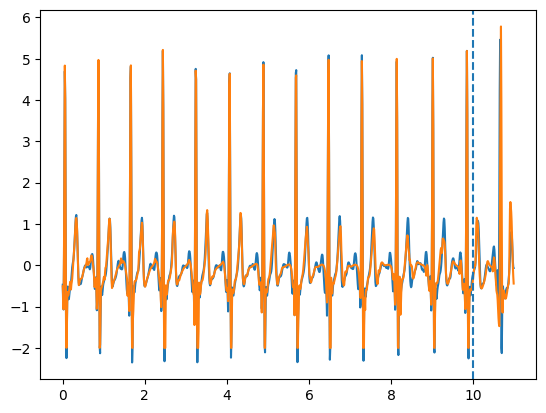

In [5]:
# Compare with and without feedback in test
with torch.no_grad():
    sim_no_feedback = heart_osc_layer(T_full, modulation=None)
    pred_no_feedback = trained_heart_model(sim_no_feedback).squeeze().cpu().numpy()

plt.plot(t_axis, true_ecg, label="true")
plt.plot(t_axis, pred_no_feedback, label="pred NO feedback")
plt.axvline(t_axis[T_train], linestyle="--")
plt.show()

In [6]:
evaluate_full(trained_heart_model, heart_osc_layer, trained_mlp, feedback_mlp,
              final_brain_params, Sc_reduced_osc, N,
              D_full_func, t_full, ecg_full_processed, cfg, device)


ECG Train | MSE: 0.0313 | Corr: 0.9836
ECG Test  | MSE: 1.2704  | Corr: 0.3789

EEG Train | MSE: 0.4766 | Corr: 0.8252
EEG Test  | MSE: 1.1554  | Corr: 0.2997


Phase diff train - mean: -0.029569149 std: 2.9420438
Phase diff test  - mean: 0.64464056 std: 3.1468832


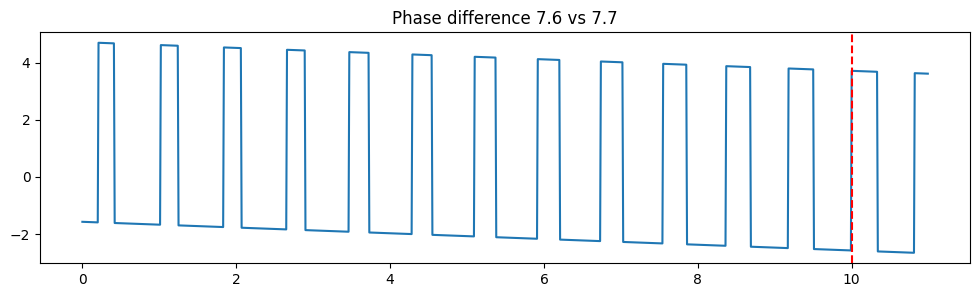

In [7]:
with torch.no_grad():
    sim = heart_osc_layer(T_full, modulation=None).cpu().numpy()
    phase1 = np.arctan2(sim[:, 1], sim[:, 0])
    phase2 = np.arctan2(sim[:, 3], sim[:, 2])
    phase_diff = phase1 - phase2
    
    print("Phase diff train - mean:", phase_diff[:T_train].mean(), "std:", phase_diff[:T_train].std())
    print("Phase diff test  - mean:", phase_diff[T_train:].mean(), "std:", phase_diff[T_train:].std())
    
    plt.figure(figsize=(12,3))
    plt.plot(t_full, phase_diff)
    plt.axvline(t_full[T_train], linestyle="--", color="red")
    plt.title("Phase difference 7.6 vs 7.7")
    plt.show()